# Segmentación **por instancia** de objetos con YOLOv11

YOLO (You Only Look Once) es una familia de modelos de detección y segmentación de objetos en tiempo real. En esta sección, se muestra cómo utilizar un modelo YOLOv11 para segmentar objetos en imágenes.

⚠️ YOLO solo implementa segmentación por instancia, lo que significa que cada objeto detectado se segmenta individualmente, en lugar de segmentar toda la imagen en regiones.

In [13]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

image_path = "./image.png"

In [14]:
# Load a pretrained YOLO11 model
model_s = YOLO("yolo11s-seg.pt")
model_m = YOLO("yolo11m-seg.pt")
model_l = YOLO("yolo11l-seg.pt")

📝 YOLO fue entrenado en el conjunto de datos COCO, que contiene 80 clases de objetos comunes. Se puede utilizar directamente el modelo YOLOv11 preentrenado para realizar segmentación de objetos en imágenes.

In [15]:
results = model_s.predict(source=image_path, device="cpu", conf=0.4, imgsz=640, verbose=True)

r = results[0]

annotated = r.plot()[:, :, ::-1]


image 1/1 /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_5/image.png: 448x640 6 persons, 2 cars, 1 backpack, 3 bottles, 1 dining table, 102.3ms
Speed: 1.6ms preprocess, 102.3ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)


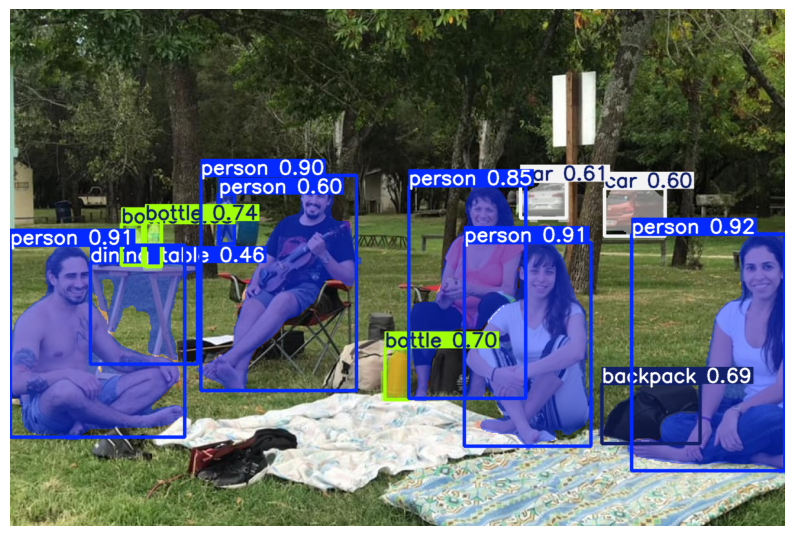

In [16]:
def plot_detections(annotated):
    plt.figure(figsize=(10, 7))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()


plot_detections(annotated)

📝 El bounding box se genera a partir de la segmentacion, no es que se ejecutan dos modelos a la vez. En base a la segmentacion, se observan los pixeles mas extremos y con esos datos se genera el bounding box

Metricas:

In [17]:
import cv2
import numpy as np

if r.masks is None:
    print("No masks detected.")
else:
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for i in range(len(r.boxes)):
        cls = int(r.boxes.cls[i].item())
        conf = r.boxes.conf[i].item()

        x1, y1, x2, y2 = map(float, r.boxes.xyxy[i].tolist())

        mask = r.masks.data[i].detach().cpu().numpy().astype(np.uint8)

        h, w = img_rgb.shape[:2]
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        area_px = int(mask.sum())

        print(
            f"Class={model_s.names[cls]}, Confidence={conf:.3f}, xyxy=[{x1:.2f}, {y1:.2f}, {x2:.2f}, {y2:.2f}], mask_area={area_px} px"
        )

Class=person, Confidence=0.919, xyxy=[962.26, 348.64, 1199.45, 714.58], mask_area=42256 px
Class=person, Confidence=0.913, xyxy=[0.08, 365.83, 270.42, 662.64], mask_area=44331 px
Class=person, Confidence=0.908, xyxy=[703.02, 361.22, 899.24, 676.02], mask_area=38959 px
Class=person, Confidence=0.902, xyxy=[295.44, 257.33, 536.73, 590.42], mask_area=28188 px
Class=person, Confidence=0.849, xyxy=[617.15, 273.79, 798.74, 602.87], mask_area=25258 px
Class=bottle, Confidence=0.742, xyxy=[210.00, 327.24, 234.84, 398.45], mask_area=2189 px
Class=bottle, Confidence=0.704, xyxy=[580.40, 524.40, 617.92, 604.42], mask_area=3165 px
Class=backpack, Confidence=0.688, xyxy=[916.73, 579.90, 1068.44, 672.03], mask_area=9172 px
Class=bottle, Confidence=0.634, xyxy=[172.66, 332.66, 205.14, 396.40], mask_area=2177 px
Class=car, Confidence=0.614, xyxy=[790.76, 266.59, 861.34, 323.20], mask_area=4277 px
Class=car, Confidence=0.603, xyxy=[920.83, 277.05, 1014.81, 351.53], mask_area=6405 px
Class=person, Confi

Mascara:

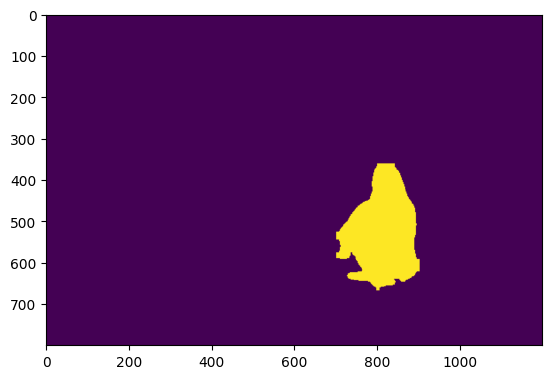

In [18]:
mask = r.masks.data[2].detach().cpu().numpy().astype(np.uint8)
h, w = img_rgb.shape[:2]
mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

plt.imshow(mask_resized)
plt.show()